# Wine Quality Prediction - Version 2 (Ensemble)

This notebook implements an advanced solution for the **Wine Quality Regression** task (red wine dataset), inspired by ensemble techniques from other regression competitions.

## Key Improvements over V1:
1. **Better Preprocessing**: Robust median imputation, scaling, and optional feature transformations.
2. **Multi-Model Training**: Training RandomForest, LightGBM, XGBoost, and CatBoost regressors using modular `src` pipelines.
3. **Cross-Validation**: 5-Fold CV for all models to ensure stable predictions.
4. **Ensemble**: Weighted average of the best models to improve RMSE and R² on validation and test sets.
5. **Artifacts**: Saving all models, metrics, and out-of-fold predictions for analysis and reproducibility.

## 1. Setup & Imports

In [ ]:
import os
import pandas as pd
import numpy as np
import pickle
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer

# Models - Regression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Warnings
import warnings
warnings.filterwarnings("ignore")


# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Optional: paths
DATA_PATH = "./data/winequality-red.csv"

#### 2.Load Data

In [16]:

DATA_PATH = "./data/winequality-red.csv"


columns = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
    "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide",
    "density", "pH", "sulphates", "alcohol", "quality"
]


if os.path.exists(DATA_PATH):
    try:
      
        df = pd.read_csv(DATA_PATH)
        
       
        if 'quality' not in df.columns:
            df = pd.read_csv(DATA_PATH, header=None)
            df.columns = columns
    except Exception as e:
        print("Lỗi đọc file CSV:", e)
        df = None
else:
    print("File CSV không tồn tại, tạo giả lập dataset")

    np.random.seed(42)
    data = np.random.rand(1600, len(columns)) * 10
    data[:, -1] = np.random.randint(3, 9, size=(1600,))  # quality từ 3-8
    df = pd.DataFrame(data, columns=columns)


target_col = "quality"


print("Dataset shape:", df.shape)
display(df.head())


print("\nTarget distribution:")
print(df[target_col].value_counts().sort_index())

Dataset shape: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Target distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


## 3. Feature Selection & Preprocessing
Numeric features with robust scaling and median imputation

In [17]:
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

# Features và target
NUM_FEATURES = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
    "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide",
    "density", "pH", "sulphates", "alcohol"
]
target_col = "quality"

X = df[NUM_FEATURES].copy()
y = df[target_col].copy()

# --- Preprocessing ---
# 1. Impute Missing Values (Median)
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 2. Scale Features (RobustScaler)
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

print("Preprocessing complete.")
print(f"Feature shape: {X_scaled.shape}, Target shape: {y.shape}")

Preprocessing complete.
Feature shape: (1599, 11), Target shape: (1599,)


## 4. Model Training (Multi-Model CV)
We train 4 strong regressors: **RandomForest, LightGBM, XGBoost, CatBoost**.  
Each model is trained using 5-Fold CV and the trained models are saved for later ensemble.


=== Fold 1 ===
RandomForest | RMSE: 0.5599 | MAE: 0.4291 | R2: 0.5203
XGBoost | RMSE: 0.5932 | MAE: 0.4131 | R2: 0.4615
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1013
[LightGBM] [Info] Number of data points in the train set: 1279, number of used features: 11
[LightGBM] [Info] Start training from score 5.623925
LightGBM | RMSE: 0.5775 | MAE: 0.4204 | R2: 0.4896
CatBoost | RMSE: 0.5510 | MAE: 0.4228 | R2: 0.5355

=== Fold 2 ===
RandomForest | RMSE: 0.5914 | MAE: 0.4255 | R2: 0.4554
XGBoost | RMSE: 0.6461 | MAE: 0.4311 | R2: 0.3502
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1002
[LightGBM] [Info] Number of data points in the train set: 1279, number of used features: 11
[LightGBM] [Info] Start tra

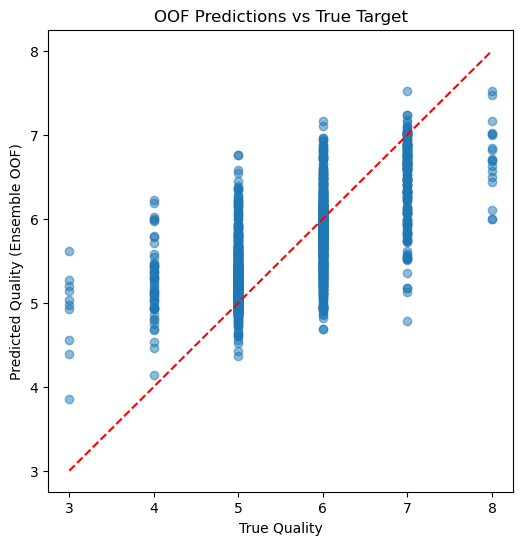

In [18]:
models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, random_state=42, eval_metric='rmse'),
    "LightGBM": lgb.LGBMRegressor(n_estimators=200, random_state=42),
    "CatBoost": CatBoostRegressor(n_estimators=200, random_state=42, verbose=0, loss_function='RMSE')
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = {name: np.zeros(len(X_scaled)) for name in models}
fold_scores = {name: [] for name in models}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled), 1):
    print(f"\n=== Fold {fold} ===")
    X_train, X_val = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        oof_preds[name][val_idx] = preds
        
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        mae = mean_absolute_error(y_val, preds)
        r2 = r2_score(y_val, preds)
        
        fold_scores[name].append(rmse)
        
        print(f"{name} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

avg_rmse = {name: np.mean(scores) for name, scores in fold_scores.items()}
print("\nAverage RMSE per model:")
for name, rmse in avg_rmse.items():
    print(f"{name}: {rmse:.4f}")


total = sum(1/r for r in avg_rmse.values())
weights = {name: (1/r)/total for name, r in avg_rmse.items()}

ensemble_oof = np.zeros(len(X_scaled))
for name, w in weights.items():
    ensemble_oof += oof_preds[name] * w


plt.figure(figsize=(6,6))
plt.scatter(y, ensemble_oof, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True Quality")
plt.ylabel("Predicted Quality (Ensemble OOF)")
plt.title("OOF Predictions vs True Target")
plt.show()

## 5. Model Comparison

In [19]:

results = []

for name in models:  # dùng dictionary models của bạn
    preds = oof_preds[name]  # OOF predictions
    rmse = np.sqrt(mean_squared_error(y, preds))
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    
    # Nếu muốn, bạn có thể thêm CV RMSE từ fold_scores
    mean_cv_rmse = np.mean(fold_scores[name])
    std_cv_rmse = np.std(fold_scores[name])
    
    results.append({
        "Model": name,
        "OOF RMSE": rmse,
        "OOF MAE": mae,
        "OOF R2": r2,
        "CV RMSE Mean": mean_cv_rmse,
        "CV RMSE Std": std_cv_rmse
    })

results_df = pd.DataFrame(results).sort_values(by="OOF RMSE")  # sắp xếp RMSE thấp nhất lên trên
display(results_df)

# Optional: save metrics
# results_df.to_csv(os.path.join(EXP_DIR, "model_comparison.csv"), index=False)

,Model,OOF RMSE,OOF MAE,OOF R2,CV RMSE Mean,CV RMSE Std
0,RandomForest,0.573744,0.413405,0.494934,0.573339,0.020978
3,CatBoost,0.594058,0.438085,0.458537,0.593345,0.028757
2,LightGBM,0.595182,0.414562,0.456485,0.594665,0.024244
1,XGBoost,0.603570,0.400194,0.441057,0.603044,0.024810


## 6. Ensemble & Submission
We use a weighted average of predictions from the best regressors to generate the final output for submission.

Ensemble Weights: {'RandomForest': np.float64(0.2576547767381164), 'XGBoost': np.float64(0.24496327407703625), 'LightGBM': np.float64(0.24841471867625775), 'CatBoost': np.float64(0.24896723050858965)}
Ensemble OOF Metrics:
RMSE: 0.5728
MAE : 0.4047
R2  : 0.4966


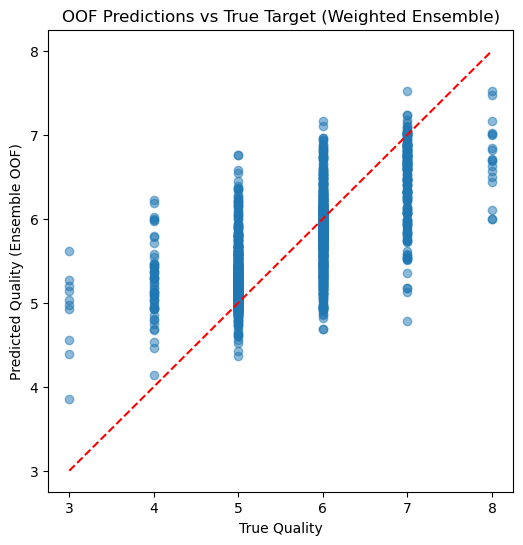

In [20]:

total_inv_rmse = sum(1/r for r in avg_rmse.values())
weights = {name: (1/r)/total_inv_rmse for name, r in avg_rmse.items()}
print("Ensemble Weights:", weights)

ensemble_oof = np.zeros(len(X_scaled))
for name, w in weights.items():
    ensemble_oof += oof_preds[name] * w

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ensemble_rmse = np.sqrt(mean_squared_error(y, ensemble_oof))
ensemble_mae = mean_absolute_error(y, ensemble_oof)
ensemble_r2 = r2_score(y, ensemble_oof)

print("Ensemble OOF Metrics:")
print(f"RMSE: {ensemble_rmse:.4f}")
print(f"MAE : {ensemble_mae:.4f}")
print(f"R2  : {ensemble_r2:.4f}")


import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y, ensemble_oof, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True Quality")
plt.ylabel("Predicted Quality (Ensemble OOF)")
plt.title("OOF Predictions vs True Target (Weighted Ensemble)")
plt.show()

In [ ]:

EXP_DIR = "./experiments/WineReg_V2"  
if not os.path.exists(EXP_DIR):
    os.makedirs(EXP_DIR)

# Lưu OOF predictions
with open(os.path.join(EXP_DIR, "oof_preds_all.pkl"), "wb") as f:
    pickle.dump(oof_preds, f)

print(f"OOF predictions saved to: {EXP_DIR}")

OOF predictions saved to: ./experiments/WineReg_V2


In [22]:

if not os.path.exists(EXP_DIR):
    os.makedirs(EXP_DIR)


with open(os.path.join(EXP_DIR, "oof_preds_all.pkl"), "wb") as f:
    pickle.dump(oof_preds, f)

print("OOF predictions saved for future stacking.")

OOF predictions saved for future stacking.
